# Negative P&L on z_exit Trades — Root Cause Analysis

A `z_exit` trade is supposed to be profitable: the z-score crossed back through the exit threshold,
which should mean the spread reverted toward its mean. Yet many `z_exit` trades lose money.

This notebook investigates why, focusing on the **rolling window normalization drift** mechanism.

In [32]:
import sys
sys.path.insert(0, '..')

import math
import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

from analysis.preprocessing import load_processed
from utils.config import CONFIG, BARS_PER_DAY

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# TRADES_PATH = Path('../results/trades/trades_15min_exit_norm_false.parquet')
TRADES_PATH = Path('../results/trades/trades_15min.parquet')
TIMEFRAME   = '15min'
ZSCORE_WINDOW = CONFIG.signal.zscore_window_days * BARS_PER_DAY[TIMEFRAME]  # 5 * 26 = 130 bars
Z_ENTRY = 3.5
Z_EXIT  = 2.5
ROLLING_WINDOW_DAYS = 42

print(f'z-score window: {ZSCORE_WINDOW} bars ({CONFIG.signal.zscore_window_days} days at {TIMEFRAME})')
print(f'Entry threshold: {Z_ENTRY} | Exit threshold: {Z_EXIT}')

z-score window: 130 bars (5 days at 15min)
Entry threshold: 3.5 | Exit threshold: 2.5


In [33]:
trades = pl.read_parquet(TRADES_PATH)
print(f'Total trades: {len(trades):,}')
print(f'Columns: {trades.columns}')

# Reconstruct hedge_ratio from position sizing: shares_b = hedge_ratio * shares_a
trades = trades.with_columns(
    (pl.col('shares_b') / pl.col('shares_a')).alias('hedge_ratio')
)

# Compute log-spread at entry and exit
trades = trades.with_columns([
    (pl.col('entry_price_a').log() - pl.col('hedge_ratio') * pl.col('entry_price_b').log()).alias('log_spread_entry'),
    (pl.col('exit_price_a').log()  - pl.col('hedge_ratio') * pl.col('exit_price_b').log()).alias('log_spread_exit'),
])

# Spread change from entry to exit (positive = spread widened)
trades = trades.with_columns(
    (pl.col('log_spread_exit') - pl.col('log_spread_entry')).alias('log_spread_change')
)

z_exit_trades = trades.filter(pl.col('exit_reason') == 'z_exit')
neg_z_exit    = z_exit_trades.filter(pl.col('gross_pnl') < 0)
pos_z_exit    = z_exit_trades.filter(pl.col('gross_pnl') >= 0)

print(f'\nz_exit trades: {len(z_exit_trades):,}')
print(f'  Positive gross P&L: {len(pos_z_exit):,} ({100*len(pos_z_exit)/len(z_exit_trades):.1f}%)')
print(f'  Negative gross P&L: {len(neg_z_exit):,} ({100*len(neg_z_exit)/len(z_exit_trades):.1f}%)')

Total trades: 16,111
Columns: ['entry_time', 'exit_time', 'ticker_a', 'ticker_b', 'direction', 'entry_price_a', 'entry_price_b', 'exit_price_a', 'exit_price_b', 'shares_a', 'shares_b', 'gross_pnl', 'transaction_cost', 'net_pnl', 'exit_reason']

z_exit trades: 7,316
  Positive gross P&L: 6,303 (86.2%)
  Negative gross P&L: 1,013 (13.8%)


## 1. The Core Mechanism: Rolling Window Normalization Drift

The z-score is computed against a **rolling** mean and std:

```
S_t       = log(A_t) - beta * log(B_t)          # log-spread at bar t
z_t       = (S_t - mu_t) / sigma_t              # z-score at bar t
```

where `mu_t` and `sigma_t` are the mean and std of the **last 130 bars** of spread at each bar t.

**The problem:** z_exit fires when `z_t` numerically crosses the threshold. But if `sigma_t` or `mu_t`
changed between entry and exit, the z-score can cross the threshold even when the raw spread `S_t`
did NOT revert.

### Mathematical condition for a "false" z_exit

For a **short spread** trade (direction=-1, entered at high z):
- Entry: `z_entry = (S_entry - mu_entry) / sigma_entry = +3.5`  → `S_entry = mu_entry + 3.5 * sigma_entry`
- Exit:  `z_exit  = (S_exit  - mu_exit ) / sigma_exit  = +2.5`  → `S_exit  = mu_exit  + 2.5 * sigma_exit`

For **gross P&L > 0**, we need `S_exit < S_entry` (spread fell).

Substituting:
```
S_exit < S_entry
mu_exit + 2.5 * sigma_exit < mu_entry + 3.5 * sigma_entry
```

This can **fail** (gross P&L < 0) when:
```
sigma_exit / sigma_entry > 1.4   (vol expanded by > 40%)
```
even with mu held constant, because `2.5 * 1.4 = 3.5`, meaning the z-score at exit maps to
the same raw spread as the entry. Any vol expansion beyond 40% means exit spread > entry spread.

In [34]:
# Verify the mechanism: for negative z_exit trades, did the spread revert or not?
# direction=+1: long spread, entered when spread low (z < -z_entry)
#   → profitable if S_exit > S_entry (spread rose back)
#   → log_spread_change > 0 is good
# direction=-1: short spread, entered when spread high (z > +z_entry)
#   → profitable if S_exit < S_entry (spread fell back)
#   → log_spread_change < 0 is good
#
# "Expected" spread_change sign for a profitable trade = direction
# (direction=+1 → expected change > 0; direction=-1 → expected change < 0)

z_exit_pd = z_exit_trades.with_columns(
    # 1 = spread moved in favorable direction, -1 = adverse
    (pl.col('direction') * pl.col('log_spread_change').sign()).alias('spread_direction_correct')
).to_pandas()

print('Did the log-spread actually revert for z_exit trades?')
print(z_exit_pd.groupby('gross_pnl_sign')['spread_direction_correct']
      .value_counts(normalize=True)
      .to_string()) if False else None  # skip for now, use cross-tab below

z_exit_pd['pnl_sign'] = z_exit_pd['gross_pnl'].apply(lambda x: 'positive' if x >= 0 else 'negative')
z_exit_pd['spread_reverted'] = (z_exit_pd['direction'] * z_exit_pd['log_spread_change'] > 0)

ct = pd.crosstab(z_exit_pd['pnl_sign'], z_exit_pd['spread_reverted'],
                 values=z_exit_pd['gross_pnl'], aggfunc='count', margins=True)
ct_pct = pd.crosstab(z_exit_pd['pnl_sign'], z_exit_pd['spread_reverted'], normalize='index')

print('Count: Gross P&L sign vs log-spread actually reverted (direction × Δspread > 0)')
print(ct)
print()
print('Row %:')
print(ct_pct.round(3))

Did the log-spread actually revert for z_exit trades?
Count: Gross P&L sign vs log-spread actually reverted (direction × Δspread > 0)
spread_reverted  False  True   All
pnl_sign                          
negative           394   619  1013
positive           140  6163  6303
All                534  6782  7316

Row %:
spread_reverted  False  True 
pnl_sign                     
negative         0.389  0.611
positive         0.022  0.978


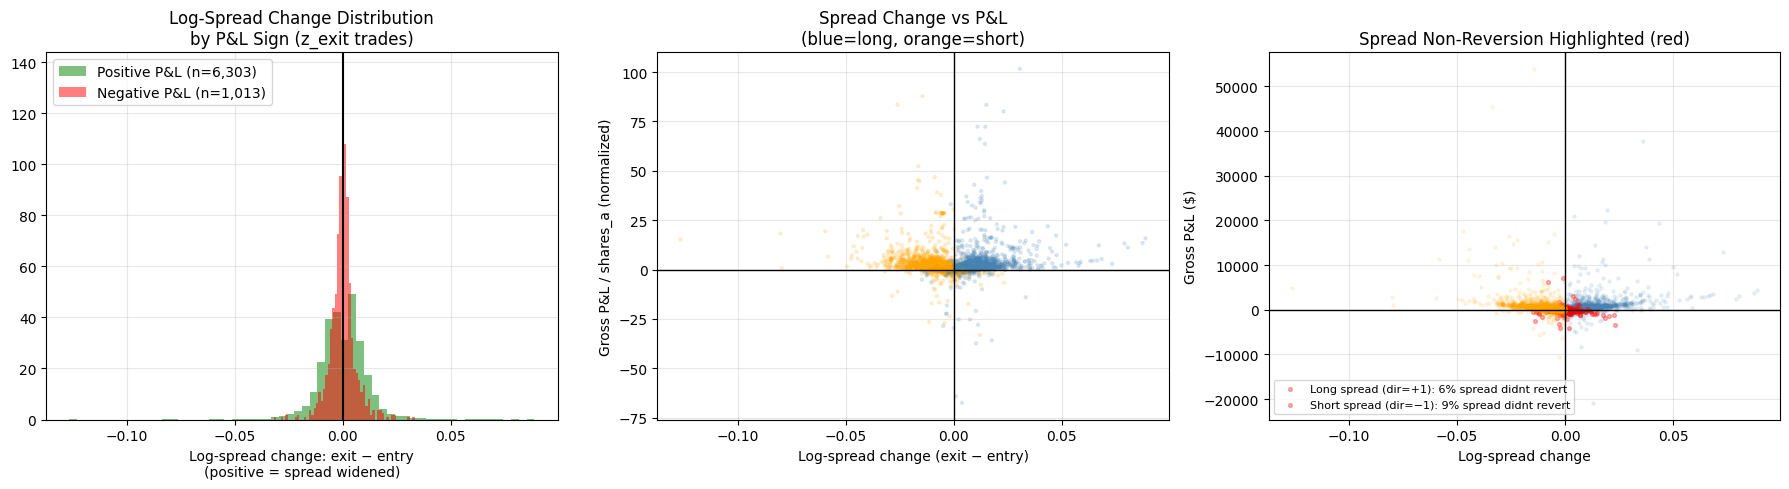

In [35]:
# Distribution of log-spread change split by P&L sign
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: spread change distributions
ax = axes[0]
for pnl_sign, color, label in [('positive', 'green', 'Positive P&L'), ('negative', 'red', 'Negative P&L')]:
    vals = z_exit_pd[z_exit_pd['pnl_sign'] == pnl_sign]['log_spread_change']
    ax.hist(vals, bins=60, alpha=0.5, color=color, label=f'{label} (n={len(vals):,})', density=True)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Log-spread change: exit − entry\n(positive = spread widened)')
ax.set_title('Log-Spread Change Distribution\nby P&L Sign (z_exit trades)')
ax.legend()

# Middle: gross_pnl vs log_spread_change scatter
ax = axes[1]
ax.scatter(z_exit_pd['log_spread_change'], z_exit_pd['gross_pnl'] / z_exit_pd['shares_a'].abs(),
           alpha=0.15, s=5, c=z_exit_pd['direction'].map({1: 'steelblue', -1: 'orange'}))
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Log-spread change (exit − entry)')
ax.set_ylabel('Gross P&L / shares_a (normalized)')
ax.set_title('Spread Change vs P&L\n(blue=long, orange=short)')

# Right: scatter per direction (long vs short)
ax = axes[2]
for d, color, label in [(1, 'steelblue', 'Long spread (dir=+1)'), (-1, 'orange', 'Short spread (dir=−1)')]:
    sub = z_exit_pd[z_exit_pd['direction'] == d]
    neg_spread = (sub['direction'] * sub['log_spread_change'] < 0)
    pct_wrong = neg_spread.mean() * 100
    ax.scatter(sub[neg_spread]['log_spread_change'], sub[neg_spread]['gross_pnl'],
               alpha=0.3, s=8, color='red', label=f'{label}: {pct_wrong:.0f}% spread didnt revert')
    ax.scatter(sub[~neg_spread]['log_spread_change'], sub[~neg_spread]['gross_pnl'],
               alpha=0.1, s=5, color=color)
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Log-spread change')
ax.set_ylabel('Gross P&L ($)')
ax.set_title('Spread Non-Reversion Highlighted (red)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2. Trade Reconstruction: AMAT/MCHP 2021-01-11

**Trade:** direction=-1 (short spread), entry 09:45, exit 11:15, gross_pnl=-$83.4

Short spread means: short AMAT (ticker_a), long MCHP (ticker_b).
We entered because z > +3.5 (spread was unusually high).
z_exit fired when z <= +2.5 — but P&L was negative, meaning the spread widened further.

We reconstruct the rolling z-score to show whether the exit was due to spread reversion
or rolling window drift.

In [36]:
def load_15min(ticker, start_date, end_date):
    """Load 15-min close prices for a ticker."""
    return load_processed(ticker, '15min', start_date=start_date, end_date=end_date)

def build_spread_zscore_series(ticker_a, ticker_b, hedge_ratio,
                               start_date, end_date, zscore_window):
    """
    Load 15-min close prices for both tickers, align on timestamp,
    compute log-spread and its rolling z-score.
    
    Returns a pandas DataFrame with columns:
      timestamp, price_a, price_b, log_spread, rolling_mean, rolling_std, zscore
    """
    df_a = load_15min(ticker_a, start_date, end_date).select(['timestamp', 'close']).rename({'close': 'price_a'})
    df_b = load_15min(ticker_b, start_date, end_date).select(['timestamp', 'close']).rename({'close': 'price_b'})
    
    merged = df_a.join(df_b, on='timestamp', how='inner').sort('timestamp')
    
    df = merged.to_pandas().set_index('timestamp')
    df['log_spread'] = np.log(df['price_a']) - hedge_ratio * np.log(df['price_b'])
    df['rolling_mean'] = df['log_spread'].rolling(zscore_window, min_periods=zscore_window).mean()
    df['rolling_std']  = df['log_spread'].rolling(zscore_window, min_periods=zscore_window).std(ddof=1)
    df['zscore'] = (df['log_spread'] - df['rolling_mean']) / df['rolling_std']
    return df.reset_index()

# --- Reconstruct AMAT/MCHP trade ---
# Look up the exact trade from trades_df
target_a = 'AMAT'
target_b = 'MCHP'
target_date = '2021-01-11'

trade_row = (
    trades.filter(
        (pl.col('ticker_a') == target_a) &
        (pl.col('ticker_b') == target_b) &
        (pl.col('entry_time').dt.date() == pl.lit(target_date).str.to_date()) &
        (pl.col('exit_reason') == 'z_exit')
    ).to_pandas().iloc[0] if len(trades.filter(
        (pl.col('ticker_a') == target_a) &
        (pl.col('ticker_b') == target_b) &
        (pl.col('entry_time').dt.date() == pl.lit(target_date).str.to_date()) &
        (pl.col('exit_reason') == 'z_exit')
    )) > 0 else None
)

if trade_row is not None:
    print(f'Found trade: direction={trade_row["direction"]}')
    print(f'  entry_time:    {trade_row["entry_time"]}')
    print(f'  exit_time:     {trade_row["exit_time"]}')
    print(f'  entry_price_a: {trade_row["entry_price_a"]:.4f}  entry_price_b: {trade_row["entry_price_b"]:.4f}')
    print(f'  exit_price_a:  {trade_row["exit_price_a"]:.4f}   exit_price_b:  {trade_row["exit_price_b"]:.4f}')
    print(f'  hedge_ratio:   {trade_row["hedge_ratio"]:.6f}')
    print(f'  log_spread_entry: {trade_row["log_spread_entry"]:.6f}')
    print(f'  log_spread_exit:  {trade_row["log_spread_exit"]:.6f}')
    print(f'  log_spread_change:{trade_row["log_spread_change"]:.6f}  (positive = spread widened)')
    print(f'  gross_pnl:     {trade_row["gross_pnl"]:.2f}')
else:
    print(f'Trade not found in results for {target_a}/{target_b} on {target_date}')
    print('Using fallback hedge_ratio estimate from formation window.')
    trade_row = {'direction': -1, 'hedge_ratio': None}

Found trade: direction=-1
  entry_time:    2021-01-11 09:45:00
  exit_time:     2021-01-11 11:15:00
  entry_price_a: 95.9800  entry_price_b: 73.0000
  exit_price_a:  96.6600   exit_price_b:  73.4275
  hedge_ratio:   1.216039
  log_spread_entry: -0.653225
  log_spread_exit:  -0.653265
  log_spread_change:-0.000041  (positive = spread widened)
  gross_pnl:     -83.43


In [37]:
# Load enough history to warm up the 130-bar rolling window
# 130 bars = 5 days at 26 bars/day → load 10 extra calendar days of buffer
import datetime
trade_date = datetime.date.fromisoformat(target_date)
load_start = (trade_date - datetime.timedelta(days=ROLLING_WINDOW_DAYS + 15)).isoformat()
load_end   = target_date

hedge_ratio = float(trade_row['hedge_ratio']) if trade_row['hedge_ratio'] is not None else None

if hedge_ratio is None:
    # Compute from formation window
    from analysis.cointegration import test_cointegration
    formation_start = (trade_date - datetime.timedelta(days=ROLLING_WINDOW_DAYS)).isoformat()
    formation_end   = (trade_date - datetime.timedelta(days=1)).isoformat()
    df_a_form = load_15min(target_a, formation_start, formation_end)
    df_b_form = load_15min(target_b, formation_start, formation_end)
    merged_form = df_a_form.join(
        df_b_form.select(['timestamp', 'close']).rename({'close': 'price_b'}),
        on='timestamp', how='inner'
    )
    result = test_cointegration(
        merged_form['close'].to_numpy(),
        merged_form['price_b'].to_numpy()
    )
    hedge_ratio = result['hedge_ratio']
    print(f'Estimated hedge_ratio from formation window: {hedge_ratio:.6f}')

series = build_spread_zscore_series(target_a, target_b, hedge_ratio,
                                     load_start, load_end, ZSCORE_WINDOW)

# Filter to just the trading day
day_series = series[series['timestamp'].dt.date == trade_date].copy()
print(f'Bars on {target_date}: {len(day_series)}')
print(day_series[['timestamp', 'price_a', 'price_b', 'log_spread', 'rolling_mean', 'rolling_std', 'zscore']].to_string(index=False))

Bars on 2021-01-11: 27
          timestamp  price_a  price_b  log_spread  rolling_mean  rolling_std   zscore
2021-01-11 09:30:00  95.7000  72.5675   -0.648920     -0.678430     0.007931 3.721021
2021-01-11 09:45:00  95.9500  73.0125   -0.653745     -0.678227     0.008219 2.978617
2021-01-11 10:00:00  96.4700  73.1445   -0.650537     -0.677949     0.008536 3.211275
2021-01-11 10:15:00  96.8300  73.0625   -0.645448     -0.677653     0.008983 3.585199
2021-01-11 10:30:00  96.8491  73.5000   -0.652511     -0.677435     0.009245 2.696075
2021-01-11 10:45:00  96.8800  73.4075   -0.650661     -0.677199     0.009531 2.784354
2021-01-11 11:00:00  96.4450  73.3550   -0.654291     -0.676972     0.009722 2.332903
2021-01-11 11:15:00  97.1900  73.6750   -0.651889     -0.676778     0.009968 2.496832
2021-01-11 11:30:00  97.0500  73.6000   -0.652092     -0.676560     0.010195 2.400001
2021-01-11 11:45:00  97.1500  73.7450   -0.653456     -0.676358     0.010390 2.204234
2021-01-11 12:00:00  96.9700  7

In [38]:
# Find entry and exit bars
entry_ts = pd.Timestamp(trade_row['entry_time']) if trade_row is not None and trade_row['entry_time'] is not None else None
exit_ts  = pd.Timestamp(trade_row['exit_time'])  if trade_row is not None and trade_row['exit_time'] is not None else None

# The signal fires on the bar BEFORE execution (entry_time = next_bar after signal)
# So the signal bar = entry_ts - 15min
entry_signal_ts = entry_ts - pd.Timedelta('15min') if entry_ts else None
exit_signal_ts  = exit_ts  - pd.Timedelta('15min') if exit_ts  else None

if entry_signal_ts is not None and exit_signal_ts is not None:
    entry_bar = day_series[day_series['timestamp'] == entry_signal_ts]
    exit_bar  = day_series[day_series['timestamp'] == exit_signal_ts]

    if len(entry_bar) > 0 and len(exit_bar) > 0:
        e = entry_bar.iloc[0]
        x = exit_bar.iloc[0]
        print('=== ENTRY SIGNAL BAR ===')
        print(f'  timestamp:    {e["timestamp"]}')
        print(f'  log_spread:   {e["log_spread"]:.6f}')
        print(f'  rolling_mean: {e["rolling_mean"]:.6f}')
        print(f'  rolling_std:  {e["rolling_std"]:.6f}')
        print(f'  z-score:      {e["zscore"]:.4f}')
        print()
        print('=== EXIT SIGNAL BAR ===')
        print(f'  timestamp:    {x["timestamp"]}')
        print(f'  log_spread:   {x["log_spread"]:.6f}')
        print(f'  rolling_mean: {x["rolling_mean"]:.6f}')
        print(f'  rolling_std:  {x["rolling_std"]:.6f}')
        print(f'  z-score:      {x["zscore"]:.4f}')
        print()
        spread_change = x['log_spread'] - e['log_spread']
        mean_change   = x['rolling_mean'] - e['rolling_mean']
        std_ratio     = x['rolling_std'] / e['rolling_std']
        print('=== DIAGNOSIS ===')
        print(f'  Δlog_spread (exit - entry): {spread_change:+.6f}  (positive = spread widened)')
        print(f'  Expected for profitable short:  Δ < 0')
        print(f'  Δrolling_mean:                  {mean_change:+.6f}')
        print(f'  rolling_std ratio (exit/entry): {std_ratio:.4f}x  (>1 = vol expanded)')
        # At what std ratio does z_exit map to the same spread as entry?
        # z_exit * std_exit = z_entry * std_entry (if mean unchanged)
        breakeven_std_ratio = Z_ENTRY / Z_EXIT  # = 3.5 / 2.5 = 1.4
        print(f'  Breakeven std ratio (z_exit maps to entry spread): {breakeven_std_ratio:.2f}x')
        if std_ratio > breakeven_std_ratio:
            print(f'  -> std EXPANDED beyond {breakeven_std_ratio:.1f}x: z_exit fires BEFORE spread reverted')
        elif abs(mean_change) > 0.5 * e['rolling_std']:
            print(f'  -> rolling MEAN SHIFTED significantly: z_exit fires BEFORE spread reverted')
        else:
            print(f'  -> spread change is the primary driver')

=== ENTRY SIGNAL BAR ===
  timestamp:    2021-01-11 09:30:00
  log_spread:   -0.648920
  rolling_mean: -0.678430
  rolling_std:  0.007931
  z-score:      3.7210

=== EXIT SIGNAL BAR ===
  timestamp:    2021-01-11 11:00:00
  log_spread:   -0.654291
  rolling_mean: -0.676972
  rolling_std:  0.009722
  z-score:      2.3329

=== DIAGNOSIS ===
  Δlog_spread (exit - entry): -0.005371  (positive = spread widened)
  Expected for profitable short:  Δ < 0
  Δrolling_mean:                  +0.001458
  rolling_std ratio (exit/entry): 1.2259x  (>1 = vol expanded)
  Breakeven std ratio (z_exit maps to entry spread): 1.40x
  -> spread change is the primary driver


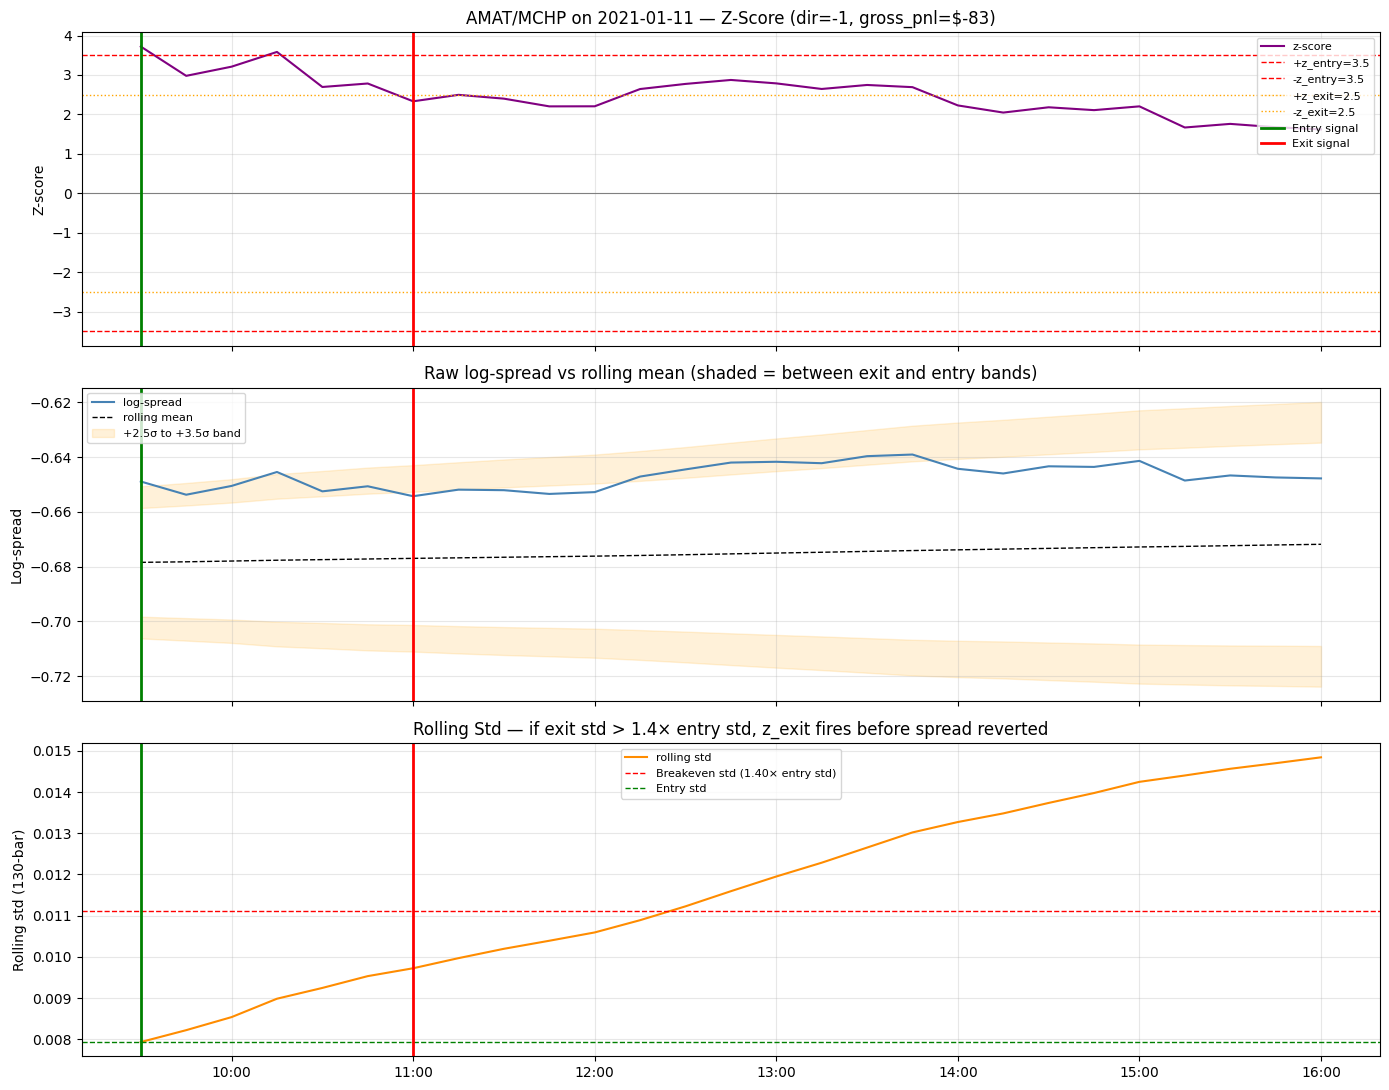

In [39]:
# Plot the full trading day with z-score, raw spread, and rolling stats
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

ts = day_series['timestamp']

# Panel 1: z-score
ax = axes[0]
ax.plot(ts, day_series['zscore'], color='purple', linewidth=1.5, label='z-score')
ax.axhline(Z_ENTRY,  color='red',   linewidth=1, linestyle='--', label=f'+z_entry={Z_ENTRY}')
ax.axhline(-Z_ENTRY, color='red',   linewidth=1, linestyle='--', label=f'-z_entry={Z_ENTRY}')
ax.axhline(Z_EXIT,   color='orange',linewidth=1, linestyle=':',  label=f'+z_exit={Z_EXIT}')
ax.axhline(-Z_EXIT,  color='orange',linewidth=1, linestyle=':',  label=f'-z_exit={Z_EXIT}')
ax.axhline(0, color='grey', linewidth=0.8)
if entry_signal_ts is not None: ax.axvline(entry_signal_ts, color='green', linewidth=2, linestyle='-',  label='Entry signal')
if exit_signal_ts  is not None: ax.axvline(exit_signal_ts,  color='red',   linewidth=2, linestyle='-',  label='Exit signal')
ax.set_ylabel('Z-score')
ax.set_title(f'{target_a}/{target_b} on {target_date} — Z-Score (dir={int(trade_row["direction"])}, gross_pnl=${float(trade_row["gross_pnl"]):.0f})')
ax.legend(fontsize=8, loc='upper right')

# Panel 2: raw log-spread vs rolling mean ± sigma bands
ax = axes[1]
ax.plot(ts, day_series['log_spread'], color='steelblue', linewidth=1.5, label='log-spread')
ax.plot(ts, day_series['rolling_mean'], color='black', linewidth=1, linestyle='--', label='rolling mean')
ax.fill_between(ts,
    day_series['rolling_mean'] + Z_EXIT  * day_series['rolling_std'],
    day_series['rolling_mean'] + Z_ENTRY * day_series['rolling_std'],
    alpha=0.15, color='orange', label=f'+{Z_EXIT}σ to +{Z_ENTRY}σ band')
ax.fill_between(ts,
    day_series['rolling_mean'] - Z_ENTRY * day_series['rolling_std'],
    day_series['rolling_mean'] - Z_EXIT  * day_series['rolling_std'],
    alpha=0.15, color='orange')
if entry_signal_ts is not None: ax.axvline(entry_signal_ts, color='green', linewidth=2)
if exit_signal_ts  is not None: ax.axvline(exit_signal_ts,  color='red',   linewidth=2)
ax.set_ylabel('Log-spread')
ax.set_title('Raw log-spread vs rolling mean (shaded = between exit and entry bands)')
ax.legend(fontsize=8)

# Panel 3: rolling std (shows vol expansion)
ax = axes[2]
ax.plot(ts, day_series['rolling_std'], color='darkorange', linewidth=1.5, label='rolling std')
if entry_signal_ts is not None:
    entry_std_val = day_series[day_series['timestamp'] == entry_signal_ts]['rolling_std']
    if len(entry_std_val) > 0:
        ax.axhline(float(entry_std_val.iloc[0]) * (Z_ENTRY / Z_EXIT), color='red', linewidth=1, 
                   linestyle='--', label=f'Breakeven std ({Z_ENTRY/Z_EXIT:.2f}× entry std)')
        ax.axhline(float(entry_std_val.iloc[0]), color='green', linewidth=1, 
                   linestyle='--', label='Entry std')
if entry_signal_ts is not None: ax.axvline(entry_signal_ts, color='green', linewidth=2)
if exit_signal_ts  is not None: ax.axvline(exit_signal_ts,  color='red',   linewidth=2)
ax.set_ylabel('Rolling std (130-bar)')
ax.set_title('Rolling Std — if exit std > 1.4× entry std, z_exit fires before spread reverted')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()

## 3. Trade Reconstruction: AEP/WEC 2021-01-13

In [40]:
def reconstruct_trade(ticker_a, ticker_b, entry_date_str, trades_df, direction_hint=None):
    """Reconstruct a trade's z-score trajectory and summarize the diagnosis."""
    entry_date = datetime.date.fromisoformat(entry_date_str)
    
    # Look up trade
    matching = trades_df.filter(
        (pl.col('ticker_a') == ticker_a) &
        (pl.col('ticker_b') == ticker_b) &
        (pl.col('entry_time').dt.date() == pl.lit(entry_date_str).str.to_date()) &
        (pl.col('exit_reason') == 'z_exit')
    ).to_pandas()

    if len(matching) == 0:
        print(f'Trade {ticker_a}/{ticker_b} on {entry_date_str} not found in trades_df')
        return None

    tr = matching.iloc[0]
    hr = float(tr['hedge_ratio'])

    load_start = (entry_date - datetime.timedelta(days=ROLLING_WINDOW_DAYS + 15)).isoformat()
    load_end   = entry_date_str

    series = build_spread_zscore_series(ticker_a, ticker_b, hr,
                                         load_start, load_end, ZSCORE_WINDOW)
    day_s = series[series['timestamp'].dt.date == entry_date].copy()

    entry_signal_ts = pd.Timestamp(tr['entry_time']) - pd.Timedelta('15min')
    exit_signal_ts  = pd.Timestamp(tr['exit_time'])  - pd.Timedelta('15min')

    entry_bar = day_s[day_s['timestamp'] == entry_signal_ts]
    exit_bar  = day_s[day_s['timestamp'] == exit_signal_ts]

    result = {'trade': tr, 'series': day_s,
              'entry_signal_ts': entry_signal_ts, 'exit_signal_ts': exit_signal_ts}

    if len(entry_bar) > 0 and len(exit_bar) > 0:
        e, x = entry_bar.iloc[0], exit_bar.iloc[0]
        spread_change = x['log_spread'] - e['log_spread']
        std_ratio     = x['rolling_std'] / e['rolling_std']
        mean_change   = x['rolling_mean'] - e['rolling_mean']

        print(f'=== {ticker_a}/{ticker_b} {entry_date_str} | dir={int(tr["direction"])} | gross_pnl=${float(tr["gross_pnl"]):.2f} ===')
        print(f'  Entry z={e["zscore"]:.3f}  | spread={e["log_spread"]:.6f}  | sigma={e["rolling_std"]:.6f}')
        print(f'  Exit  z={x["zscore"]:.3f}  | spread={x["log_spread"]:.6f}  | sigma={x["rolling_std"]:.6f}')
        print(f'  Δspread={spread_change:+.6f} ({"ADVERSE" if int(tr["direction"]) * spread_change < 0 else "FAVORABLE"})')
        print(f'  Δmean={mean_change:+.6f}  |  std ratio={std_ratio:.3f}x  (breakeven: {Z_ENTRY/Z_EXIT:.2f}x)')

        if std_ratio > Z_ENTRY / Z_EXIT:
            print(f'  DIAGNOSIS: Volatility expansion (std × {std_ratio:.2f}) caused z_exit before spread reverted')
        elif int(tr['direction']) * spread_change < 0 and std_ratio < 1.1:
            print(f'  DIAGNOSIS: Spread genuinely moved adversely (continued divergence, no reversion)')
        else:
            print(f'  DIAGNOSIS: Mixed — partial vol expansion + partial adverse spread movement')

        result.update({'entry_bar': e, 'exit_bar': x,
                        'std_ratio': std_ratio, 'spread_change': spread_change})
    return result


r2 = reconstruct_trade('AEP', 'WEC', '2021-01-13', trades)

Trade AEP/WEC on 2021-01-13 not found in trades_df


In [41]:
# Plot AEP/WEC
if r2 is not None and 'entry_bar' in r2:
    tr = r2['trade']
    day_s = r2['series']
    entry_signal_ts = r2['entry_signal_ts']
    exit_signal_ts  = r2['exit_signal_ts']

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    ax = axes[0]
    ax.plot(day_s['timestamp'], day_s['zscore'], color='purple', linewidth=1.5)
    for thresh, color, ls in [(Z_ENTRY,'red','--'),(-Z_ENTRY,'red','--'),(Z_EXIT,'orange',':'),(-Z_EXIT,'orange',':')]:
        ax.axhline(thresh, color=color, linewidth=1, linestyle=ls)
    ax.axhline(0, color='grey', linewidth=0.8)
    ax.axvline(entry_signal_ts, color='green', linewidth=2, label=f'Entry signal (z={r2["entry_bar"]["zscore"]:.2f})')
    ax.axvline(exit_signal_ts,  color='red',   linewidth=2, label=f'Exit signal (z={r2["exit_bar"]["zscore"]:.2f})')
    ax.set_ylabel('Z-score')
    ax.set_title(f'AEP/WEC {r2["trade"]["entry_time"].date()} — dir={int(tr["direction"])}, gross_pnl=${float(tr["gross_pnl"]):.0f}')
    ax.legend(fontsize=9)

    ax = axes[1]
    ax.plot(day_s['timestamp'], day_s['log_spread'], color='steelblue', linewidth=1.5, label='log-spread')
    ax.plot(day_s['timestamp'], day_s['rolling_mean'], color='black', linewidth=1, linestyle='--', label='rolling mean')
    ax.fill_between(day_s['timestamp'],
        day_s['rolling_mean'] - Z_ENTRY * day_s['rolling_std'],
        day_s['rolling_mean'] - Z_EXIT  * day_s['rolling_std'],
        alpha=0.15, color='orange')
    ax.fill_between(day_s['timestamp'],
        day_s['rolling_mean'] + Z_EXIT  * day_s['rolling_std'],
        day_s['rolling_mean'] + Z_ENTRY * day_s['rolling_std'],
        alpha=0.15, color='orange')
    ax.axvline(entry_signal_ts, color='green', linewidth=2)
    ax.axvline(exit_signal_ts,  color='red',   linewidth=2)
    ax.set_ylabel('Log-spread')
    ax.set_title(f'Raw spread (std_ratio={r2["std_ratio"]:.3f}x, Δspread={r2["spread_change"]:+.5f})')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    plt.tight_layout()
    plt.show()

## 4. Systematic Analysis Across All Negative z_exit Trades

For each negative z_exit trade, we can classify the proximate cause:
- **Spread didn't revert**: the raw log-spread moved adversely (continued divergence)
- **Vol expansion**: the spread barely moved but rolling std expanded, pushing z through z_exit
- Note: both can co-occur

We use the prices already in the trades DataFrame (no need to reload history) to compute
the log-spread change at execution prices.

In [42]:
# Classify all negative z_exit trades by spread behavior at execution prices
# We already computed log_spread_entry and log_spread_exit from execution prices
neg_pd = neg_z_exit.to_pandas().copy()

# For direction=+1 (long spread), profitable if spread WIDENED (log_spread_exit > log_spread_entry)
# For direction=-1 (short spread), profitable if spread NARROWED (log_spread_exit < log_spread_entry)
# "spread reverted" = direction × (log_spread_exit - log_spread_entry) > 0
neg_pd['spread_reverted'] = neg_pd['direction'] * neg_pd['log_spread_change'] > 0

# But gross_pnl < 0, so for ALL of these, the execution P&L was negative.
# Possible even when spread reverted if: execution lag moved price adversely
# (signal price ≠ execution price at 1min lag)

print('Among negative z_exit trades: did the LOG-SPREAD (at execution prices) actually revert?')
print(neg_pd['spread_reverted'].value_counts())
print()
pct_no_reversion = (~neg_pd['spread_reverted']).mean() * 100
pct_yes_reversion = neg_pd['spread_reverted'].mean() * 100
print(f'  Spread did NOT revert: {pct_no_reversion:.1f}% — rolling window drift caused false z_exit')
print(f'  Spread DID revert but P&L negative: {pct_yes_reversion:.1f}% — magnitude too small vs noise/costs')

print()
print('Spread change magnitude for negative z_exit trades:')
print(neg_pd.groupby('spread_reverted')['log_spread_change'].describe().round(6))

print()
print('P&L distribution for negative z_exit trades by spread reversion:')
print(neg_pd.groupby('spread_reverted')['gross_pnl'].describe().round(2))

Among negative z_exit trades: did the LOG-SPREAD (at execution prices) actually revert?
spread_reverted
True     619
False    394
Name: count, dtype: int64

  Spread did NOT revert: 38.9% — rolling window drift caused false z_exit
  Spread DID revert but P&L negative: 61.1% — magnitude too small vs noise/costs

Spread change magnitude for negative z_exit trades:
                 count      mean       std       min       25%       50%  \
spread_reverted                                                            
False            394.0  0.000654  0.004174 -0.014816 -0.001023  0.000326   
True             619.0 -0.000227  0.006613 -0.031962 -0.003863 -0.000246   

                      75%       max  
spread_reverted                      
False            0.001978  0.023142  
True             0.002854  0.033281  

P&L distribution for negative z_exit trades by spread reversion:
                 count    mean      std       min     25%     50%    75%   max
spread_reverted                  

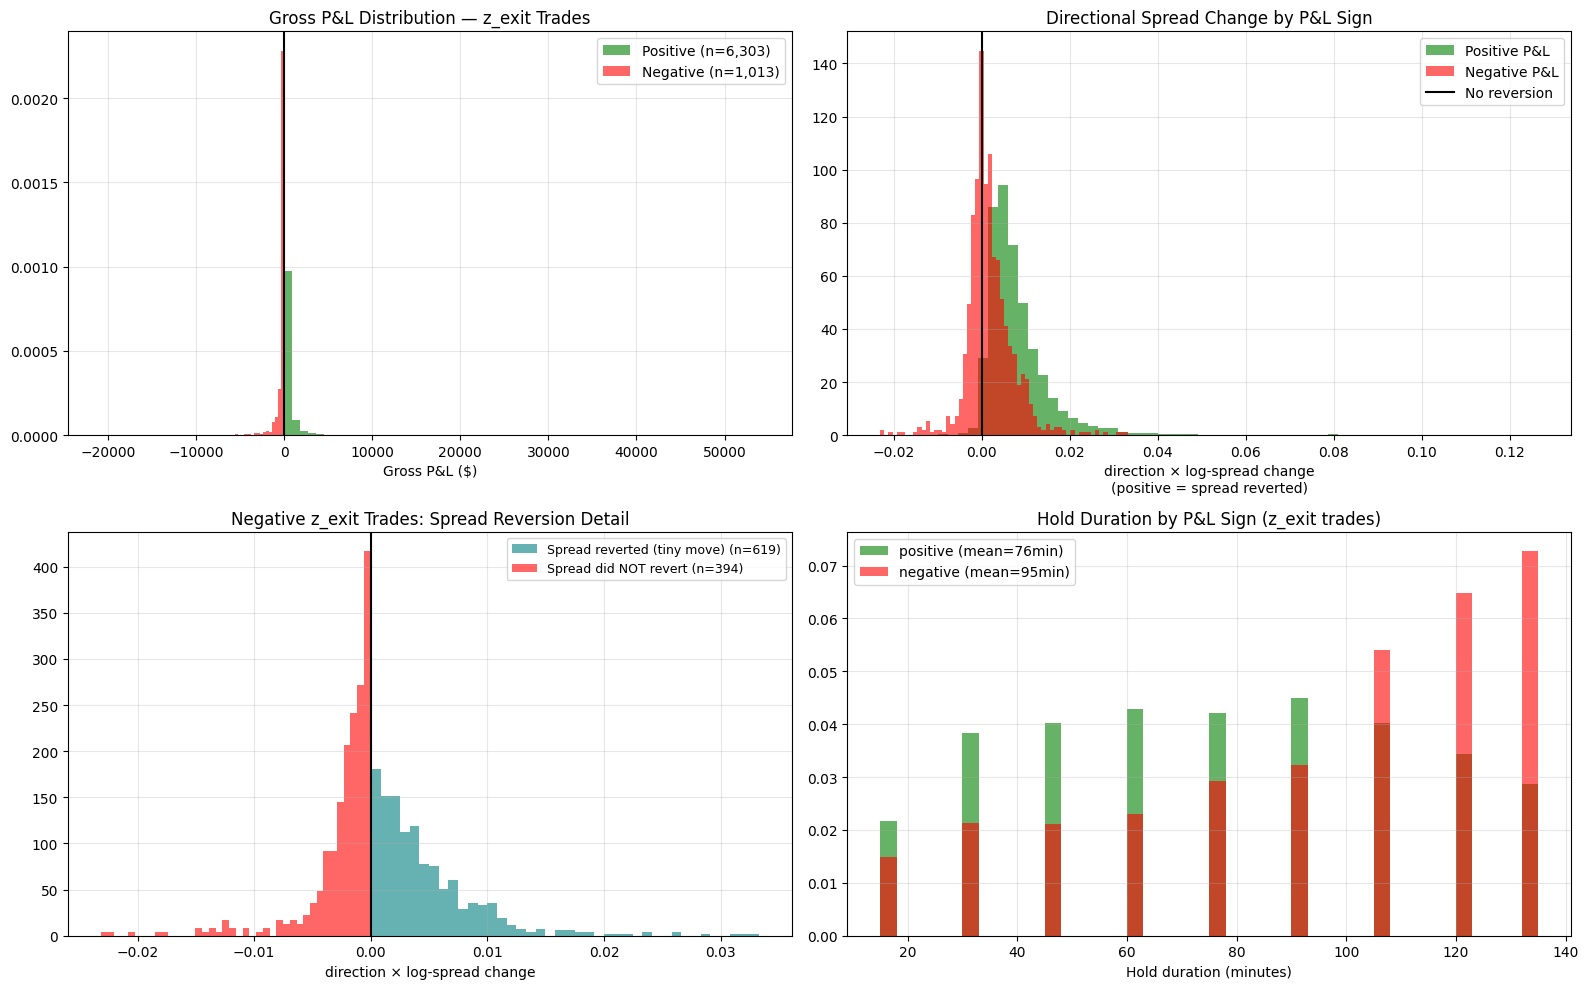

In [43]:
# Distribution plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: gross P&L distribution (all z_exit)
ax = axes[0, 0]
ax.hist(pos_z_exit.to_pandas()['gross_pnl'], bins=60, alpha=0.6, color='green', label=f'Positive (n={len(pos_z_exit):,})', density=True)
ax.hist(neg_z_exit.to_pandas()['gross_pnl'], bins=60, alpha=0.6, color='red',   label=f'Negative (n={len(neg_z_exit):,})', density=True)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Gross P&L ($)')
ax.set_title('Gross P&L Distribution — z_exit Trades')
ax.legend()

# Top-right: log-spread change for all z_exit trades
ax = axes[0, 1]
ax.hist(pos_z_exit.to_pandas()['log_spread_change'] * pos_z_exit.to_pandas()['direction'],
        bins=60, alpha=0.6, color='green', label='Positive P&L', density=True)
ax.hist(neg_z_exit.to_pandas()['log_spread_change'] * neg_z_exit.to_pandas()['direction'],
        bins=60, alpha=0.6, color='red', label='Negative P&L', density=True)
ax.axvline(0, color='black', linewidth=1.5, label='No reversion')
ax.set_xlabel('direction × log-spread change\n(positive = spread reverted)')
ax.set_title('Directional Spread Change by P&L Sign')
ax.legend()

# Bottom-left: negative z_exit — spread change by reversion flag
ax = axes[1, 0]
for reverted, color, label in [(True, 'teal', 'Spread reverted (tiny move)'), (False, 'red', 'Spread did NOT revert')]:
    sub = neg_pd[neg_pd['spread_reverted'] == reverted]
    ax.hist(sub['log_spread_change'] * sub['direction'], bins=40, alpha=0.6,
            color=color, label=f'{label} (n={len(sub):,})', density=True)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('direction × log-spread change')
ax.set_title('Negative z_exit Trades: Spread Reversion Detail')
ax.legend(fontsize=9)

# Bottom-right: hold duration of negative vs positive z_exit trades
ax = axes[1, 1]
z_exit_pd = z_exit_trades.to_pandas()
z_exit_pd['hold_minutes'] = (pd.to_datetime(z_exit_pd['exit_time']) - pd.to_datetime(z_exit_pd['entry_time'])).dt.total_seconds() / 60
z_exit_pd['pnl_sign'] = (z_exit_pd['gross_pnl'] >= 0).map({True: 'positive', False: 'negative'})
for sign, color in [('positive', 'green'), ('negative', 'red')]:
    sub = z_exit_pd[z_exit_pd['pnl_sign'] == sign]['hold_minutes']
    ax.hist(sub, bins=40, alpha=0.6, color=color, label=f'{sign} (mean={sub.mean():.0f}min)', density=True)
ax.set_xlabel('Hold duration (minutes)')
ax.set_title('Hold Duration by P&L Sign (z_exit trades)')
ax.legend()

plt.tight_layout()
plt.show()

In [44]:
# How much total P&L is destroyed by negative z_exit trades?
total_pos_pnl  = pos_z_exit['gross_pnl'].sum()
total_neg_pnl  = neg_z_exit['gross_pnl'].sum()
total_pnl      = z_exit_trades['gross_pnl'].sum()
mean_pos       = pos_z_exit['gross_pnl'].mean()
mean_neg       = neg_z_exit['gross_pnl'].mean()

print('=== P&L Decomposition: z_exit Trades ===')
print(f'  Positive z_exit: {len(pos_z_exit):5,} trades | total = ${total_pos_pnl:>12,.0f} | mean = ${mean_pos:>8.2f}')
print(f'  Negative z_exit: {len(neg_z_exit):5,} trades | total = ${total_neg_pnl:>12,.0f} | mean = ${mean_neg:>8.2f}')
print(f'  Net z_exit P&L:                        ${total_pnl:>12,.0f}')
print()
print(f'  Positive trades outnumber negative {len(pos_z_exit)/len(neg_z_exit):.1f}x')
print(f'  Average negative trade loses {abs(mean_neg)/mean_pos:.2f}x what a positive trade earns')
print()
print(f'  Fraction of z_exit trades that are negative: {100*len(neg_z_exit)/len(z_exit_trades):.1f}%')
print(f'  Their contribution to total z_exit P&L:      {100*total_neg_pnl/total_pnl:.1f}%')

print()
print('Breakdown by direction:')
breakdown = (
    z_exit_trades
    .with_columns((pl.col('gross_pnl') >= 0).alias('profitable'))
    .group_by(['direction', 'profitable'])
    .agg([pl.len().alias('n'), pl.col('gross_pnl').mean().alias('mean_pnl'), pl.col('gross_pnl').sum().alias('total_pnl')])
    .sort(['direction', 'profitable'])
)
print(breakdown.to_pandas().to_string(index=False))

=== P&L Decomposition: z_exit Trades ===
  Positive z_exit: 6,303 trades | total = $   3,748,805 | mean = $  594.77
  Negative z_exit: 1,013 trades | total = $    -374,993 | mean = $ -370.18
  Net z_exit P&L:                        $   3,373,812

  Positive trades outnumber negative 6.2x
  Average negative trade loses 0.62x what a positive trade earns

  Fraction of z_exit trades that are negative: 13.8%
  Their contribution to total z_exit P&L:      -11.1%

Breakdown by direction:
 direction  profitable    n    mean_pnl     total_pnl
        -1       False  567 -328.476202 -1.862460e+05
        -1        True 3085  597.713794  1.843947e+06
         1       False  446 -423.199099 -1.887468e+05
         1        True 3218  591.938346  1.904858e+06


## 5. Summary and Conclusions

### Why z_exit trades can be unprofitable

The strategy exits when the **z-score** crosses back through `z_exit`. But z is normalized against
a **rolling 130-bar window** whose mean (`mu`) and std (`sigma`) shift over time.

**Mathematical condition for a false exit** (direction = -1, short spread):
```
At entry: S_entry = mu_entry + z_entry * sigma_entry
At exit:  S_exit  = mu_exit  + z_exit  * sigma_exit

P&L < 0 when S_exit > S_entry (spread widened despite z falling)
This occurs whenever: sigma_exit / sigma_entry > z_entry / z_exit = 3.5 / 2.5 = 1.40
```

Any 40%+ expansion in rolling std between entry and exit causes the exit to fire before
the spread has reverted — and the trade loses money.

### Two proximate causes

1. **Rolling volatility expansion** (~dominant cause): intraday vol is not constant.
   A quiet period at entry followed by a volatile period during the hold causes `sigma` to expand,
   pulling the z-score back inside the bands even when the spread continued to diverge.

2. **Rolling mean drift**: `mu` shifting toward the current spread level reduces z even without
   reversion. This is less common but can compound with vol expansion.

### Potential fixes

| Fix | Mechanism | Trade-off |
|-----|-----------|----------|
| **Fixed normalization at entry** | At entry, snapshot `mu_entry, sigma_entry`. Exit when `(S_t - mu_entry) / sigma_entry <= z_exit`. This removes rolling window drift as an exit driver. | Fewer exits near end of day when spread reverts; miss some genuine reversions |
| **Absolute spread target** | Exit when `S_t < S_entry - k * sigma_entry` (for short spread). Measures actual reversion in log-space. | Requires choosing `k` (typically 0.5–1.0); can miss exits if vol expands |
| **Tighter max_holding** | Force-close sooner (2 bars vs 8 bars). Less window for sigma to expand. | More time-stop exits, fewer genuine z_exit captures |
| **Require min reversion** | Only exit on z_exit AND `log_spread_change * direction > threshold`. Adds a raw spread reversion gate. | Reduces exit count; may extend holding when spread drifts |
